In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,MaxPool2D,Conv2D,Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Pixel value range:", X_train.min(), "-", X_train.max())

Train shape: (60000, 28, 28) Test shape: (10000, 28, 28)
Pixel value range: 0 - 255


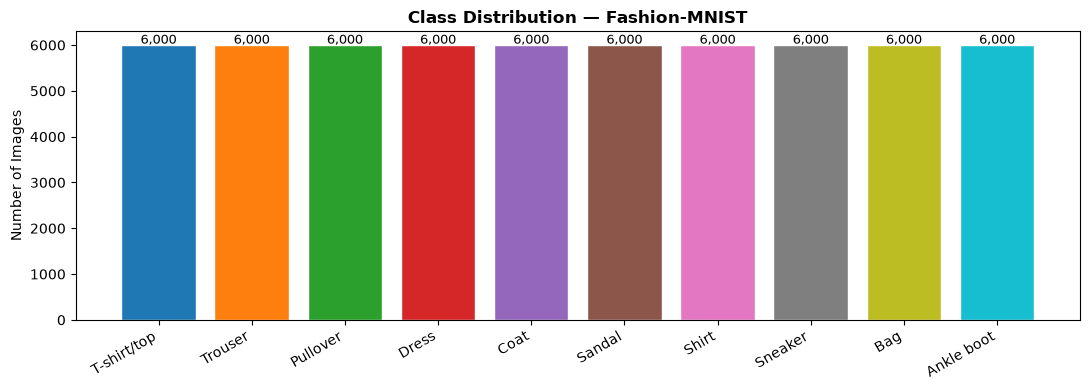

In [3]:
unique, counts = np.unique(y_train, return_counts=True)
colors = plt.cm.tab10(np.linspace(0, 1, 10))

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar([class_names[i] for i in unique], counts, color=colors, edgecolor='white')
ax.set_title('Class Distribution — Fashion-MNIST', fontweight='bold')
ax.set_ylabel('Number of Images')
plt.xticks(rotation=30, ha='right')
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
             f'{val:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

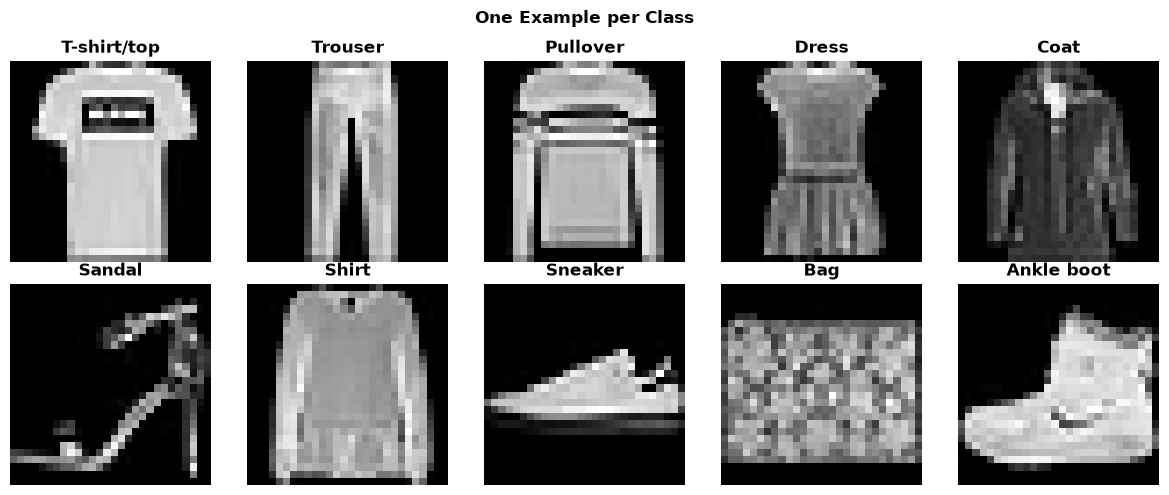

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    idx = np.where(y_train == i)[0][0]
    ax.imshow(X_train[idx], cmap='gray')
    ax.set_title(class_names[i], fontweight='bold')
    ax.axis('off')
plt.suptitle('One Example per Class', fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\nikhi\AppData\Local\Temp\ipykernel_25920\3754194619.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(class_names, rotation=30, ha='right')


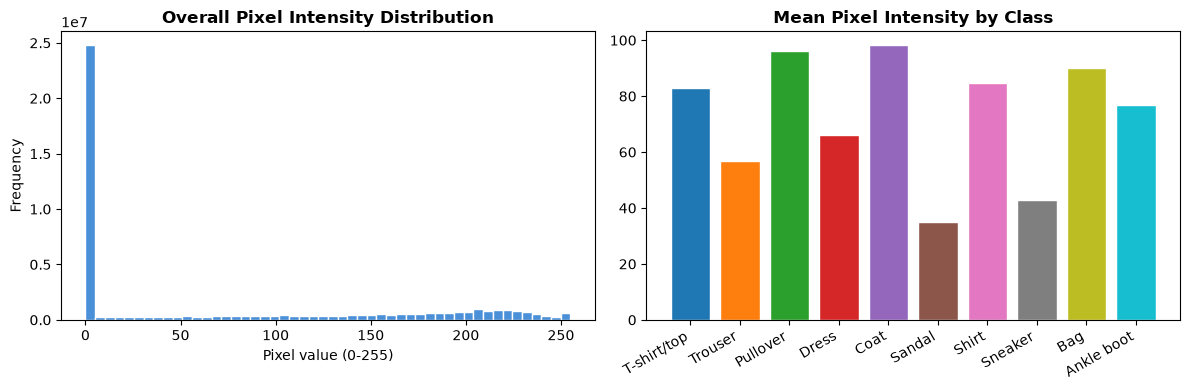

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_train.flatten(), bins=50, color='#4A90D9', edgecolor='white')
axes[0].set_title('Overall Pixel Intensity Distribution', fontweight='bold')
axes[0].set_xlabel('Pixel value (0-255)')
axes[0].set_ylabel('Frequency')

mean_intensity_per_class = [X_train[y_train == i].mean() for i in range(10)]
axes[1].bar(class_names, mean_intensity_per_class, color=colors, edgecolor='white')
axes[1].set_title('Mean Pixel Intensity by Class', fontweight='bold')
axes[1].set_xticklabels(class_names, rotation=30, ha='right')

plt.tight_layout()
plt.show()

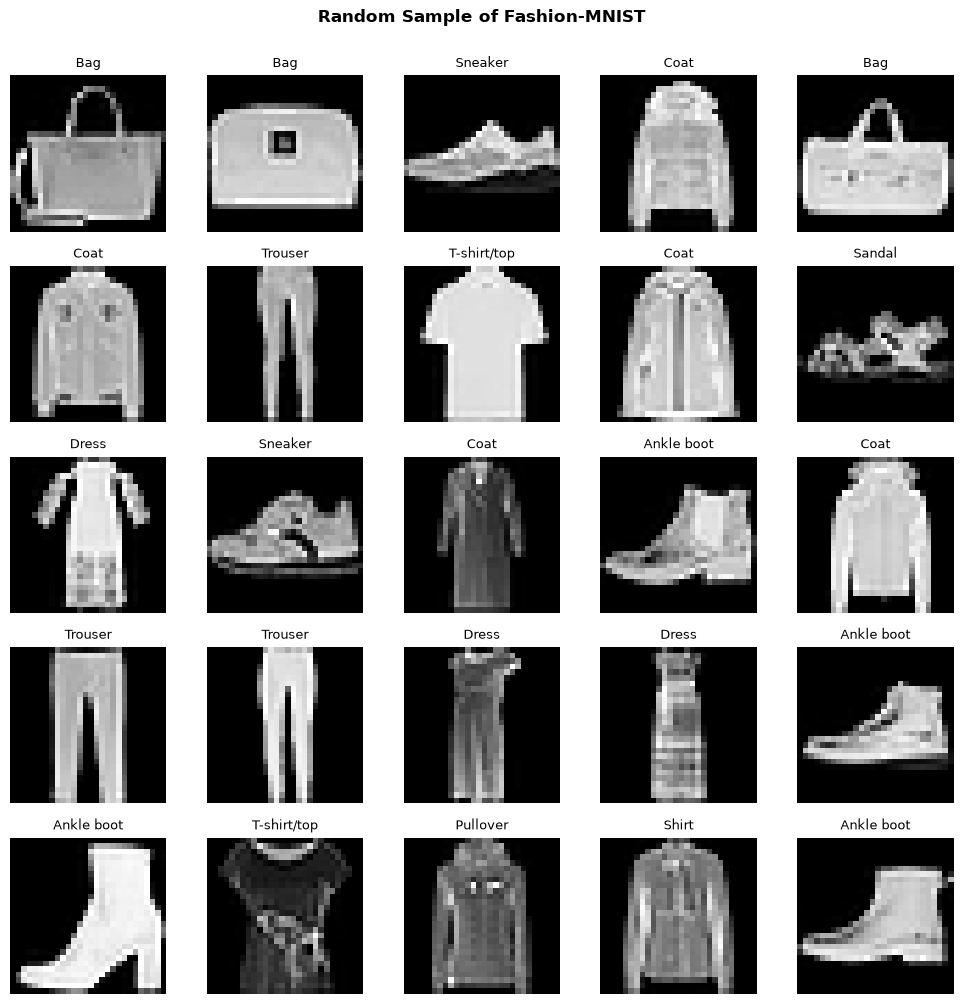

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Show 25 random images with their labels — this is literally what's in the dataset
plt.figure(figsize=(10, 10))
np.random.seed(42)
random_idx = np.random.choice(len(X_train), 25, replace=False)
for i, idx in enumerate(random_idx):
    plt.subplot(5, 5, i+1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(class_names[y_train[idx]], fontsize=9)
    plt.axis('off')
plt.suptitle('Random Sample of Fashion-MNIST', fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()

In [7]:
# Normalize pixel values to 0-1, reshape to add the channel dimension (grayscale = 1 channel)
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

X_train_norm = X_train_norm.reshape(-1, 28, 28, 1)
X_test_norm = X_test_norm.reshape(-1, 28, 28, 1)

print("Train shape:", X_train_norm.shape, "Test shape:", X_test_norm.shape)

Train shape: (60000, 28, 28, 1) Test shape: (10000, 28, 28, 1)


In [8]:
from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom

data_augmentation = tf.keras.Sequential([
    RandomFlip("horizontal"),      # mirrors left-right (fine for clothing, unlike digits)
    RandomRotation(0.08),          # closest layer-based equivalent to shear_range
    RandomZoom(0.2),               # same idea as zoom_range in your cat/dog notebook
])

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense, Dropout

cnn = Sequential([
    Input(shape=(28, 28, 1)),
    data_augmentation,              # <- only active during training, ignored at test time
    Conv2D(filters=32, kernel_size=3, activation='relu'),
    MaxPool2D(pool_size=2, strides=2),
    Conv2D(filters=64, kernel_size=3, activation='relu'),
    MaxPool2D(pool_size=2, strides=2),
    Flatten(),
    Dense(units=128, activation='relu'),
    Dropout(0.3),
    Dense(units=10, activation='softmax')
])

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

history = cnn.fit(
    X_train_norm, y_train,
    validation_data=(X_test_norm, y_test),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 13ms/step - accuracy: 0.7117 - loss: 0.7739 - val_accuracy: 0.7703 - val_loss: 0.5934
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7872 - loss: 0.5702 - val_accuracy: 0.8112 - val_loss: 0.5022
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8088 - loss: 0.5150 - val_accuracy: 0.8295 - val_loss: 0.4479
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8257 - loss: 0.4698 - val_accuracy: 0.8428 - val_loss: 0.4351
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8371 - loss: 0.4460 - val_accuracy: 0.8444 - val_loss: 0.4210
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8420 - loss: 0.4280 - val_accuracy: 0.8506 - val_loss: 0.4169
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8470 - loss: 0.4106 - val_accuracy: 0.8545 - val_loss: 0.4047
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8517 - loss: 

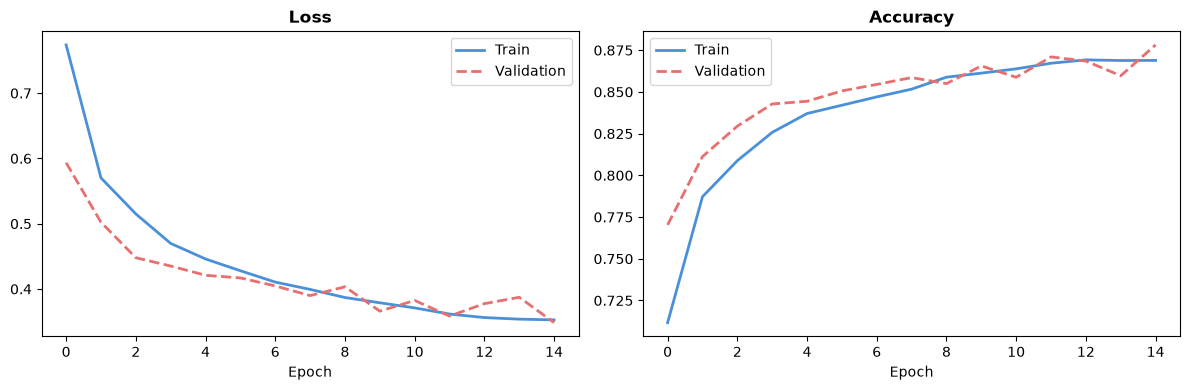

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train', color='#4A90D9', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation', color='#E76F6F', linewidth=2, linestyle='--')
axes[0].set_title('Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train', color='#4A90D9', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation', color='#E76F6F', linewidth=2, linestyle='--')
axes[1].set_title('Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_acc = cnn.evaluate(X_test_norm, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

y_pred_probs = cnn.predict(X_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)   # softmax outputs 10 probabilities -> take the highest

print(classification_report(y_test, y_pred, target_names=class_names))

Test accuracy: 0.8782
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.82      0.84      0.83      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.76      0.88      0.82      1000
       Dress       0.89      0.88      0.88      1000
        Coat       0.87      0.71      0.78      1000
      Sandal       0.96      0.97      0.96      1000
       Shirt       0.65      0.67      0.66      1000
     Sneaker       0.93      0.94      0.94      1000
         Bag       0.96      0.97      0.97      1000
  Ankle boot       0.97      0.94      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



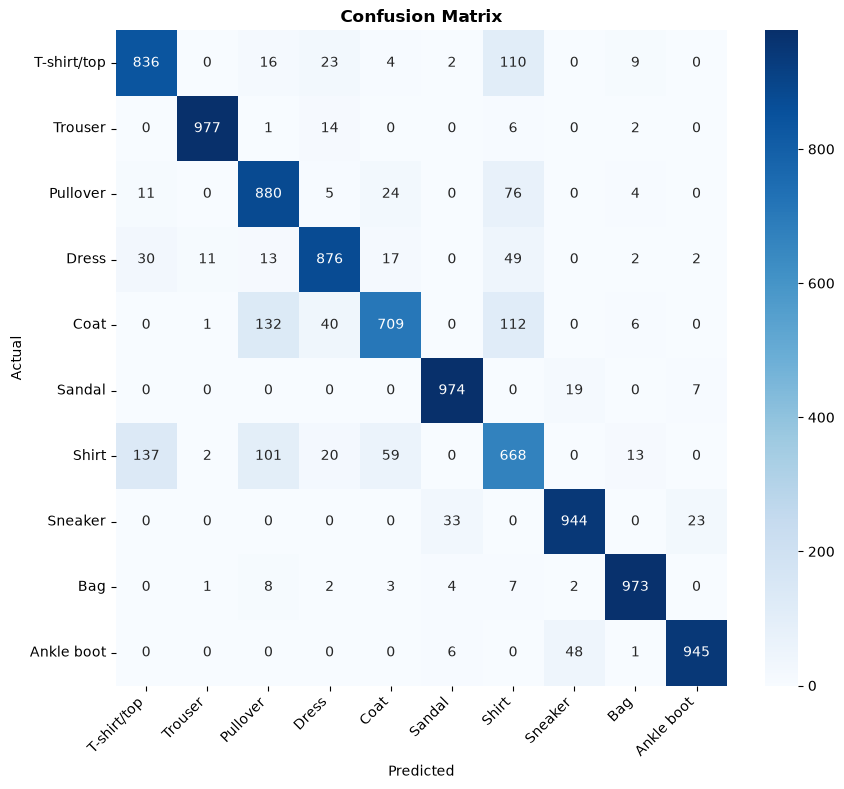

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

cnn = Sequential([
    Input(shape=(28, 28, 1)),
    data_augmentation,

    Conv2D(filters=32, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(pool_size=2, strides=2),

    Conv2D(filters=64, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(pool_size=2, strides=2),

    Conv2D(filters=128, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPool2D(pool_size=2, strides=2),

    Flatten(),
    Dense(units=256, activation='relu'),
    Dropout(0.4),
    Dense(units=10, activation='softmax')
])

cnn.compile(optimizer=Adam(learning_rate=0.0005),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])
cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,306 (1.49 MB)

 Trainable params: 390,858 (1.49 MB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

history = cnn.fit(
    X_train_norm, y_train,
    validation_data=(X_test_norm, y_test),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 51s 15ms/step - accuracy: 0.7526 - loss: 0.6784 - val_accuracy: 0.8067 - val_loss: 0.5165 - learning_rate: 5.0000e-04
Epoch 2/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8204 - loss: 0.4887 - val_accuracy: 0.8290 - val_loss: 0.4555 - learning_rate: 5.0000e-04
Epoch 3/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8418 - loss: 0.4305 - val_accuracy: 0.8477 - val_loss: 0.4253 - learning_rate: 5.0000e-04
Epoch 4/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8512 - loss: 0.4017 - val_accuracy: 0.8688 - val_loss: 0.3640 - learning_rate: 5.0000e-04
Epoch 5/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8619 - loss: 0.3770 - val_accuracy: 0.8746 - val_loss: 0.3371 - learning_rate: 5.0000e-04
Epoch 6/30
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8679 - loss: 0.3636 - val_accuracy: 0.8759 - val_loss: 0.3396 - learning_rate: 5.0000e-04
Epoch 7/30
1875/1875 ━━━━━━━━━━━━━━━━━━━

In [16]:
from sklearn.metrics import classification_report, confusion_matrix

test_loss, test_acc = cnn.evaluate(X_test_norm, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

y_pred_probs = cnn.predict(X_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=class_names))

Test accuracy: 0.9142
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

 T-shirt/top       0.86      0.86      0.86      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.90      0.86      0.88      1000
       Dress       0.93      0.90      0.91      1000
        Coat       0.85      0.88      0.86      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.74      0.76      0.75      1000
     Sneaker       0.94      0.98      0.96      1000
         Bag       0.98      0.99      0.98      1000
  Ankle boot       0.98      0.95      0.97      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



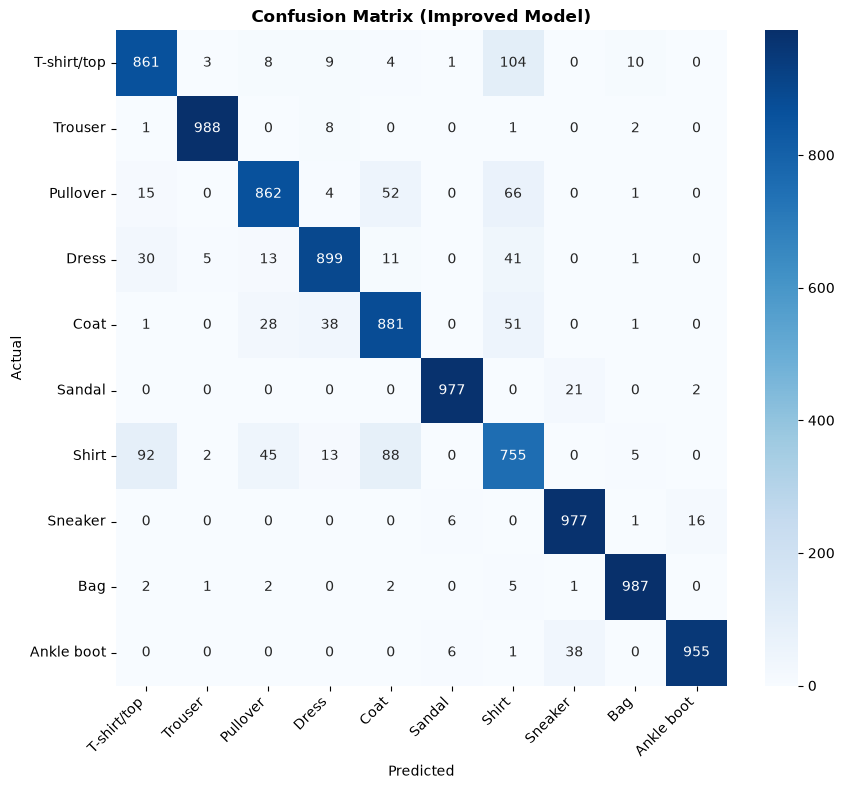

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Improved Model)', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()